# IoT Intrusion Detection — XGBoost

### Objective
Train and tune `XGBClassifier` — the project's gradient-boosted candidate —
comparing feature-count subsets on validation data, then freezing the best
configuration for the final test evaluation in notebook 11.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve

_candidates = [Path.cwd(), Path.cwd() / "scripts", Path.cwd().parent / "scripts",
               Path.cwd().parent, Path.cwd().parent.parent / "scripts"]
_scripts_dir = next((c for c in _candidates if (c / "common.py").exists()), None)
if _scripts_dir is None:
    raise FileNotFoundError(f"Could not locate scripts/common.py from cwd={Path.cwd()}")
sys.path.insert(0, str(_scripts_dir))
from common import (PROCESSED_DIR, FEATSEL_DIR, MODELS_DIR, METRICS_DIR, FIGURES_DIR,
                     RANDOM_STATE, eval_binary, fit_time, predict_full, model_size_mb)

plt.rcParams.update({"figure.dpi": 100, "font.size": 10})

## 1. Load Tree-Oriented Data and Feature Sets

In [2]:
def load_tree_data():
    X_train = pd.read_csv(PROCESSED_DIR / "X_train_tree.csv")
    y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv")["Label"]
    X_val = pd.read_csv(PROCESSED_DIR / "X_validation_tree.csv")
    y_val = pd.read_csv(PROCESSED_DIR / "y_validation.csv")["Label"]
    return X_train, y_train, X_val, y_val


def load_feature_sets():
    sets = {}
    for k in [10, 15, 20, 30]:
        sets[k] = (FEATSEL_DIR / f"top_{k}_features.txt").read_text().splitlines()
    sets["All"] = (FEATSEL_DIR / "all_selected_features.txt").read_text().splitlines()
    return sets


X_train, y_train, X_val, y_val = load_tree_data()
feature_sets = load_feature_sets()
print(f"Train: {X_train.shape} | Validation: {X_val.shape}")

Train: (295484, 72) | Validation: (73872, 72)


## 2. Class Imbalance: `scale_pos_weight`, Computed Correctly

`scale_pos_weight` is conventionally `count(negative) / count(positive)`,
where "positive" is class 1. In this dataset, **Anomaly (1) is the
majority class** (~92%), so this ratio comes out *below* 1 — using it
naively would down-weight the already-dominant class even further, the
opposite of what imbalance correction should do. It is computed here from
**training labels only** for transparency, but the actual balancing
mechanism used for every fit is `compute_sample_weight("balanced", ...)`,
which correctly up-weights whichever class is smaller regardless of its
numeric code.

In [3]:
def calculate_scale_pos_weight(y_train):
    neg = int((y_train == 0).sum())
    pos = int((y_train == 1).sum())
    return neg / pos, neg, pos


spw, n_neg, n_pos = calculate_scale_pos_weight(y_train)
print(f"Training class counts -> Normal(0): {n_neg:,}  Anomaly(1): {n_pos:,}")
print(f"scale_pos_weight (neg/pos) = {spw:.4f}  <-- below 1: confirms Anomaly is the MAJORITY class")
print("Using compute_sample_weight('balanced', ...) instead, for correct-direction balancing.")

sw_train = compute_sample_weight(class_weight="balanced", y=y_train)

Training class counts -> Normal(0): 24,702  Anomaly(1): 270,782
scale_pos_weight (neg/pos) = 0.0912  <-- below 1: confirms Anomaly is the MAJORITY class
Using compute_sample_weight('balanced', ...) instead, for correct-direction balancing.


## 3. Feature-Count Experiments (Validation Only)

In [4]:
def evaluate_xgboost(model, X, y):
    pred, proba, pred_t = predict_full(model, X)
    return eval_binary(y, pred, proba), pred_t


def run_xgb_feature_count_experiments(feature_sets, X_train, y_train, X_val, y_val, sample_weight):
    rows = []
    for k, feats in feature_sets.items():
        model = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, tree_method="hist",
                                   random_state=RANDOM_STATE, n_jobs=-1, eval_metric="logloss")
        train_t = fit_time(model, X_train[feats], y_train, sample_weight=sample_weight)
        metrics, pred_t = evaluate_xgboost(model, X_val[feats], y_val)
        rows.append({"Model": "XGBoost", "Feature_Count": k if k != "All" else len(feats),
                      "Feature_Set": k, **metrics, "Training_Time": train_t, "Inference_Time": pred_t})
    return pd.DataFrame(rows)


feature_count_results = run_xgb_feature_count_experiments(feature_sets, X_train, y_train, X_val, y_val, sw_train)
print(feature_count_results[["Feature_Set", "Macro_F1", "ROC_AUC", "Training_Time"]].to_string(index=False))

best_k = feature_count_results.loc[feature_count_results["Macro_F1"].idxmax(), "Feature_Set"]
best_feats = feature_sets[best_k]
print(f"\nBest feature set by validation Macro-F1: {best_k} ({len(best_feats)} features)")

Feature_Set  Macro_F1  ROC_AUC  Training_Time
         10  0.995246 0.999903       3.291871
         15  0.996034 0.999878       3.275870
         20  0.995946 0.999909       3.856592
         30  0.996165 0.999900       4.133228
        All  0.996296 0.999929       7.750783

Best feature set by validation Macro-F1: All (72 features)


## 4. Bounded Hyperparameter Tuning (Train + Validation Only)

A small, hand-picked grid is used for the same reason as notebook 08:
avoiding nested process-based parallelism (`RandomizedSearchCV(n_jobs=-1)`
wrapping an estimator that also sets `n_jobs=-1`) that deadlocks inside a
Jupyter kernel process in this environment.

In [5]:
def tune_xgboost(X_train, y_train, X_val, y_val, sample_weight):
    candidates = [
        {"n_estimators": 100, "max_depth": 4, "learning_rate": 0.1, "subsample": 0.8,
         "colsample_bytree": 0.8, "min_child_weight": 1, "reg_alpha": 0, "reg_lambda": 1.0},
        {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.1, "subsample": 0.9,
         "colsample_bytree": 0.8, "min_child_weight": 3, "reg_alpha": 0.01, "reg_lambda": 1.0},
        {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.05, "subsample": 0.8,
         "colsample_bytree": 1.0, "min_child_weight": 5, "reg_alpha": 0.1, "reg_lambda": 1.5},
        {"n_estimators": 200, "max_depth": 8, "learning_rate": 0.2, "subsample": 0.9,
         "colsample_bytree": 0.6, "min_child_weight": 1, "reg_alpha": 0, "reg_lambda": 2.0},
        {"n_estimators": 400, "max_depth": 5, "learning_rate": 0.05, "subsample": 1.0,
         "colsample_bytree": 0.8, "min_child_weight": 3, "reg_alpha": 0.01, "reg_lambda": 1.0},
        {"n_estimators": 300, "max_depth": 4, "learning_rate": 0.1, "subsample": 0.7,
         "colsample_bytree": 0.8, "min_child_weight": 5, "reg_alpha": 1.0, "reg_lambda": 0.5},
    ]
    best = {"score": -1}
    for params in candidates:
        model = xgb.XGBClassifier(**params, tree_method="hist", random_state=RANDOM_STATE,
                                   n_jobs=-1, eval_metric="logloss")
        model.fit(X_train, y_train, sample_weight=sample_weight)
        metrics, _ = evaluate_xgboost(model, X_val, y_val)
        print(f"  {params} -> Macro_F1={metrics['Macro_F1']:.4f}")
        if metrics["Macro_F1"] > best["score"]:
            best = {"score": metrics["Macro_F1"], "params": params, "metrics": metrics}
    return best


sw_train_best = compute_sample_weight(class_weight="balanced", y=y_train)
tuning_result = tune_xgboost(X_train[best_feats], y_train, X_val[best_feats], y_val, sw_train_best)
print("\nBest params:", tuning_result["params"])

  {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'reg_alpha': 0, 'reg_lambda': 1.0} -> Macro_F1=0.9934
  {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.9, 'colsample_bytree': 0.8, 'min_child_weight': 3, 'reg_alpha': 0.01, 'reg_lambda': 1.0} -> Macro_F1=0.9957
  {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 1.0, 'min_child_weight': 5, 'reg_alpha': 0.1, 'reg_lambda': 1.5} -> Macro_F1=0.9950
  {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.2, 'subsample': 0.9, 'colsample_bytree': 0.6, 'min_child_weight': 1, 'reg_alpha': 0, 'reg_lambda': 2.0} -> Macro_F1=0.9967
  {'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 1.0, 'colsample_bytree': 0.8, 'min_child_weight': 3, 'reg_alpha': 0.01, 'reg_lambda': 1.0} -> Macro_F1=0.9945
  {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.7, 

## 5. Freeze the Final XGBoost Model

In [6]:
final_xgb = xgb.XGBClassifier(**tuning_result["params"], tree_method="hist", random_state=RANDOM_STATE,
                               n_jobs=-1, eval_metric="logloss")
final_train_t = fit_time(final_xgb, X_train[best_feats], y_train, sample_weight=sw_train_best)
final_pred, final_proba, final_pred_t = predict_full(final_xgb, X_val[best_feats])
final_metrics = eval_binary(y_val, final_pred, final_proba)
print("Frozen model validation metrics:", final_metrics)

Frozen model validation metrics: {'Accuracy': 0.998998267273121, 'Macro_Precision': 0.996658668615247, 'Macro_Recall': 0.9968048257188797, 'Macro_F1': 0.9967317340321796, 'Weighted_F1': 0.9989983409599522, 'Balanced_Accuracy': 0.9968048257188797, 'ROC_AUC': 0.99988922015582, 'PR_AUC': 0.9999891815575737, 'Normal_Precision': np.float64(0.99384914211719), 'Normal_Recall': np.float64(0.9941709844559585), 'Normal_F1': np.float64(0.9940100372349037), 'Anomaly_Precision': np.float64(0.999468195113304), 'Anomaly_Recall': np.float64(0.999438666981801), 'Anomaly_F1': np.float64(0.9994534308294556)}


## 6. Diagnostic Plots and Feature Importance

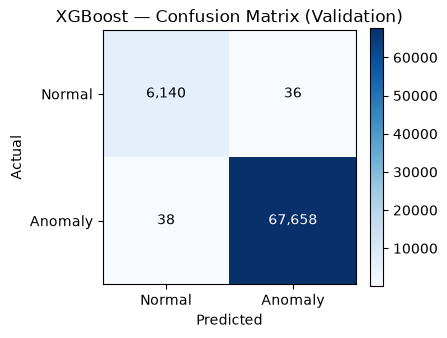

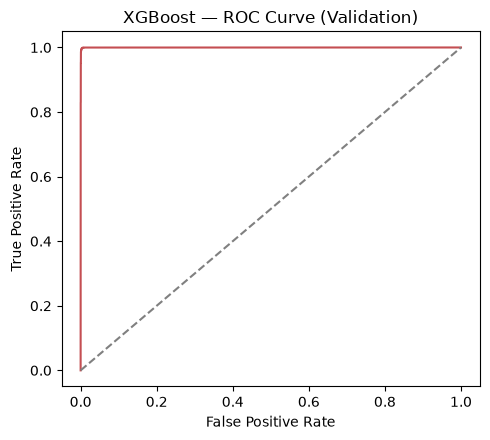

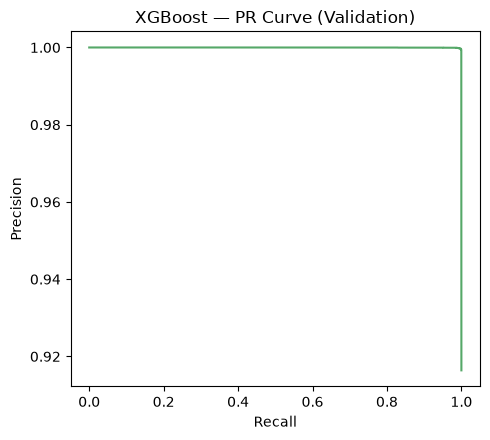

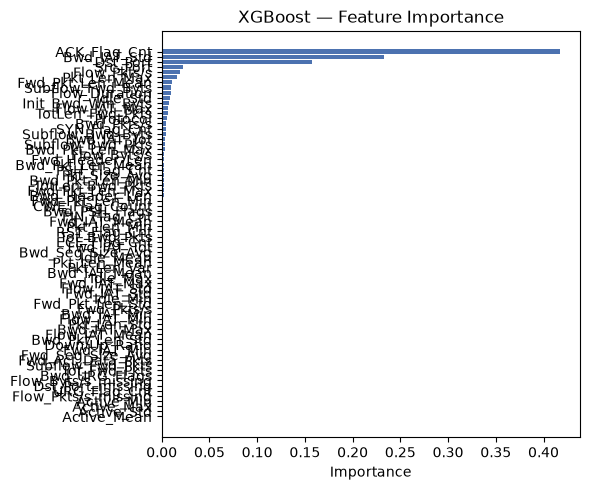

Saved 4 figures to figures/


In [7]:
def plot_confusion_matrix(y_true, y_pred, title, save_name):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Normal", "Anomaly"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Normal", "Anomaly"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / save_name, bbox_inches="tight")
    plt.show()
    return cm


def plot_roc_curve(y_true, y_proba, title, save_name):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    fig, ax = plt.subplots(figsize=(5, 4.5))
    ax.plot(fpr, tpr, color="#C44E52")
    ax.plot([0, 1], [0, 1], linestyle="--", color="grey")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate"); ax.set_title(title)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / save_name, bbox_inches="tight")
    plt.show()


def plot_pr_curve(y_true, y_proba, title, save_name):
    prec, rec, _ = precision_recall_curve(y_true, y_proba)
    fig, ax = plt.subplots(figsize=(5, 4.5))
    ax.plot(rec, prec, color="#55A868")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_title(title)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / save_name, bbox_inches="tight")
    plt.show()


def plot_feature_importance(model, features, title, save_name):
    imp = pd.Series(model.feature_importances_, index=features).sort_values()
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.barh(imp.index, imp.values, color="#4C72B0")
    ax.set_title(title); ax.set_xlabel("Importance")
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / save_name, bbox_inches="tight")
    plt.show()


plot_confusion_matrix(y_val, final_pred, "XGBoost — Confusion Matrix (Validation)", "xgb_confusion_matrix.png")
plot_roc_curve(y_val, final_proba, "XGBoost — ROC Curve (Validation)", "xgb_roc_curve.png")
plot_pr_curve(y_val, final_proba, "XGBoost — PR Curve (Validation)", "xgb_pr_curve.png")
plot_feature_importance(final_xgb, best_feats, "XGBoost — Feature Importance", "xgb_feature_importance.png")
print("Saved 4 figures to figures/")

## 7. Save Model, Model Size, and Metrics

In [8]:
def calculate_model_size(path):
    return model_size_mb(path)


def save_model(model, features, best_params, path):
    joblib.dump({"model": model, "features": features, "best_params": best_params}, path)
    print(f"Saved: {path}  ({calculate_model_size(path)} MB)")


save_model(final_xgb, best_feats, tuning_result["params"], MODELS_DIR / "xgboost.joblib")
xgb_model_size_mb = calculate_model_size(MODELS_DIR / "xgboost.joblib")

feature_count_results.to_csv(METRICS_DIR / "xgboost_metrics.csv", index=False)
print("Saved: metrics/xgboost_metrics.csv")

Saved: C:\Users\dhruv\OneDrive\KLH Univeristy\4th semester (Trimester Format KLH)\25SC2107E Machine Learning\Project\models\xgboost.joblib  (0.921 MB)
Saved: metrics/xgboost_metrics.csv


## Notebook Summary

In [9]:
from IPython.display import display, Markdown

summary_md = f"""
- Computed `scale_pos_weight` from training labels only
  ({spw:.4f} = {n_neg:,}/{n_pos:,}) and confirmed it would balance in the
  **wrong direction** here since Anomaly is the majority class — used
  `compute_sample_weight("balanced", ...)` for actual training instead.
- Ran feature-count experiments (10/15/20/30/All) on **validation data only**;
  best subset: **{best_k}**
  (Macro-F1={feature_count_results.set_index('Feature_Set').loc[best_k, 'Macro_F1']:.4f}).
- Bounded manual grid search (6 configurations) found: {tuning_result['params']}.
- Froze the final model — validation Macro-F1={final_metrics['Macro_F1']:.4f},
  ROC-AUC={final_metrics['ROC_AUC']:.4f}, model size={xgb_model_size_mb} MB.
- Saved `models/xgboost.joblib`, `metrics/xgboost_metrics.csv`, and 4 figures.

**Next notebook (`10_Explainability_SHAP.ipynb`)** explains the strongest
candidate model's predictions using SHAP (with a documented, working fallback
if unavailable).
"""
display(Markdown(summary_md))


- Computed `scale_pos_weight` from training labels only
  (0.0912 = 24,702/270,782) and confirmed it would balance in the
  **wrong direction** here since Anomaly is the majority class — used
  `compute_sample_weight("balanced", ...)` for actual training instead.
- Ran feature-count experiments (10/15/20/30/All) on **validation data only**;
  best subset: **All**
  (Macro-F1=0.9963).
- Bounded manual grid search (6 configurations) found: {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.2, 'subsample': 0.9, 'colsample_bytree': 0.6, 'min_child_weight': 1, 'reg_alpha': 0, 'reg_lambda': 2.0}.
- Froze the final model — validation Macro-F1=0.9967,
  ROC-AUC=0.9999, model size=0.921 MB.
- Saved `models/xgboost.joblib`, `metrics/xgboost_metrics.csv`, and 4 figures.

**Next notebook (`10_Explainability_SHAP.ipynb`)** explains the strongest
candidate model's predictions using SHAP (with a documented, working fallback
if unavailable).
